In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torchvision.transforms as transforms


libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
import sys, torch
print("python:", sys.executable)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

python: /root/miniconda3/bin/python
cuda: True
gpu: NVIDIA GeForce RTX 4090


In [3]:
# 1. 多尺度特征提取模块
class MultiScaleFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3):
        super(MultiScaleFeatureExtractor, self).__init__()
        # 128x128 卷积核
        self.conv_128 = nn.Conv2d(in_channels, 1, kernel_size=128, stride=1, padding=0)
        # 64x64 卷积核
        self.conv_64 = nn.Conv2d(in_channels, 1, kernel_size=64, stride=1, padding=0)
        # 32x32 卷积核
        self.conv_32 = nn.Conv2d(in_channels, 1, kernel_size=32, stride=1, padding=0)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: [B, 3, 1024, 1024]
        f_128 = self.relu(self.conv_128(x))  # [B, 1, 897, 897]
        f_64 = self.relu(self.conv_64(x))    # [B, 1, 961, 961]
        f_32 = self.relu(self.conv_32(x))    # [B, 1, 993, 993]
        return f_128, f_64, f_32


In [4]:
# 2. 多尺度特征金字塔模块（包含贝叶斯启发融合）
class MultiScaleFeaturePyramid(nn.Module):
    def __init__(self):
        super(MultiScaleFeaturePyramid, self).__init__()
        # 1x1卷积投影到统一通道数32
        self.proj_128 = nn.Conv2d(1, 32, kernel_size=1)
        self.proj_64 = nn.Conv2d(1, 32, kernel_size=1)
        self.proj_32 = nn.Conv2d(1, 32, kernel_size=1)

        # 下采样到128x128的可训练线性层
        self.downsample_128 = nn.Conv2d(32, 32, kernel_size=1)
        self.downsample_64 = nn.Conv2d(32, 32, kernel_size=1)
        self.downsample_32 = nn.Conv2d(32, 32, kernel_size=1)

        # 贝叶斯启发融合模块
        self.bayesian_fusion = nn.Conv2d(96, 32, kernel_size=1)

    def forward(self, f_128, f_64, f_32):
        # 投影到统一通道数
        p_128 = self.proj_128(f_128)  # [B, 32, 897, 897]
        p_64 = self.proj_64(f_64)     # [B, 32, 961, 961]
        p_32 = self.proj_32(f_32)     # [B, 32, 993, 993]

        # 下采样到128x128
        p_128_ds = F.interpolate(p_128, size=(128, 128), mode='bilinear')
        p_64_ds = F.interpolate(p_64, size=(128, 128), mode='bilinear')
        p_32_ds = F.interpolate(p_32, size=(128, 128), mode='bilinear')

        # 贝叶斯启发融合
        combined = torch.cat([p_128_ds, p_64_ds, p_32_ds], dim=1)  # [B, 96, 128, 128]
        p_4 = self.bayesian_fusion(combined)  # [B, 32, 128, 128]

        return p_128_ds, p_64_ds, p_32_ds, p_4


In [5]:
# 3. 病理扩散点推断模块
class PathologicalDiffusionInference(nn.Module):
    def __init__(self, window_size=16):
        super(PathologicalDiffusionInference, self).__init__()
        # 可训练权重系数alpha_i（每个金字塔层级一个）
        self.alpha_1 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_2 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_3 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_4 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)

        # 1x1卷积用于特征变换
        self.f_transform = nn.Conv2d(32, 32, kernel_size=1)
        self.f_transform2 = nn.Conv2d(32, 32, kernel_size=1)

        # 输入投影
        self.input_proj = nn.Conv2d(3, 32, kernel_size=1)

        # window 大小（窗口化 diffusion）
        self.window_size = window_size

    def _window_partition(self, x):
        # x: [B, C, H, W] -> x_win: [B*nWin, C, ws*ws]
        B, C, H, W = x.shape
        ws = self.window_size

        # padding 到 ws 的整数倍，避免 H/W 不能整除
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h != 0 or pad_w != 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='constant', value=0)

        Hp, Wp = x.shape[-2], x.shape[-1]
        nH = Hp // ws
        nW = Wp // ws

        # [B, C, nH, ws, nW, ws] -> [B, nH, nW, C, ws, ws]
        x = x.view(B, C, nH, ws, nW, ws).permute(0, 2, 4, 1, 3, 5).contiguous()
        # [B*nH*nW, C, ws*ws]
        x = x.view(B * nH * nW, C, ws * ws)

        return x, (H, W), (Hp, Wp), (nH, nW)

    def _window_unpartition(self, x_win, orig_hw, padded_hw, grid_hw):
        # x_win: [B*nWin, C, ws*ws] -> [B, C, H, W]
        H, W = orig_hw
        Hp, Wp = padded_hw
        nH, nW = grid_hw
        ws = self.window_size

        # 推回到 [B, nH, nW, C, ws, ws]
        # 这里 B 通过 nWin 推出来：nWin = nH*nW
        nWin = nH * nW
        B = x_win.shape[0] // nWin
        C = x_win.shape[1]

        x = x_win.view(B, nH, nW, C, ws, ws)
        # [B, C, nH, ws, nW, ws] -> [B, C, Hp, Wp]
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous().view(B, C, Hp, Wp)

        # 裁回原始 H,W
        return x[:, :, :H, :W]

    def compute_affinity_window(self, x, y):
        # x, y: [B, 32, H, W]（通常是 128×128）
        # 返回 affinity: [B*nWin, ws*ws, ws*ws]，以及 partition 信息用于还原
        x_win, orig_hw, padded_hw, grid_hw = self._window_partition(x)
        y_win, _,       _,        _       = self._window_partition(y)

        # x_win: [B*nWin, C, N]，N=ws*ws
        # affinity: [B*nWin, N, N]
        affinity = torch.bmm(x_win.transpose(1, 2), y_win) / np.sqrt(8)
        affinity = F.softmax(affinity, dim=-1)

        return affinity, x_win, orig_hw, padded_hw, grid_hw

    def forward(self, p_list, input_image):
        # p_list: [p1, p2, p3, p4]  (通常都是 [B,32,128,128])
        # input_image: [B, 3, 1024, 1024]

        # 处理输入图像
        input_ds = F.interpolate(input_image, size=(128, 128), mode='bilinear', align_corners=False)
        y = self.input_proj(input_ds)  # [B, 32, 128, 128]

        refined_features = []
        for i, (p_i, alpha) in enumerate(zip(p_list, [self.alpha_1, self.alpha_2, self.alpha_3, self.alpha_4])):
            # 计算条件概率 P(X_i | Y_i)（窗口化 affinity）
            affinity, x_win, orig_hw, padded_hw, grid_hw = self.compute_affinity_window(p_i, y)

            # rho_x: [B,32,H,W] -> [B*nWin,32,N]
            rho_x = self.f_transform(p_i)
            rho_x_win, _, _, _ = self._window_partition(rho_x)

            # p_cond_win: [B*nWin, N, 32] -> [B*nWin, 32, N]
            p_cond_win = torch.bmm(affinity, rho_x_win.transpose(1, 2))
            p_cond_win = p_cond_win.transpose(1, 2)

            # 还原回 [B, 32, H, W]
            p_cond = self._window_unpartition(p_cond_win, orig_hw, padded_hw, grid_hw)

            # 特征变换 F(Y_i)
            f_y = F.relu(self.f_transform2(y))

            # 融合
            refined = alpha * p_cond * f_y
            refined_features.append(refined)

            # 更新y为当前 refined 特征
            y = refined

        return refined_features[-1]  # 返回最后一个精炼特征

In [6]:
# 4. 解码和分类层
class Decoder(nn.Module):
    def __init__(self, num_classes=2):
        super(Decoder, self).__init__()
        self.upsample = nn.ConvTranspose2d(
            32, num_classes, kernel_size=2, stride=2
        )

    def forward(self, x):
        return self.upsample(x)  # [B, 2, 256, 256]

In [7]:
# 5. CRF正则化损失
class CRFLoss(nn.Module):
    def __init__(self):
        super(CRFLoss, self).__init__()

    def forward(self, predictions, targets):
        # predictions: [B, 2, 1024, 1024] (softmax输出)
        # targets: [B, 1024, 1024] (0或1)

        B, C, H, W = predictions.shape
        predictions = predictions.view(B, C, -1)
        targets = targets.view(B, -1)

        # 一元势函数
        p_tumor = predictions[:, 1, :]  # 肿瘤概率
        p_bg = predictions[:, 0, :]     # 背景概率

        # CRF损失
        crf_loss = -torch.mean(targets * torch.log(p_tumor + 1e-8) +
                               (1 - targets) * torch.log(p_bg + 1e-8))
        return crf_loss

In [8]:
# 6. 完整的MSF-net模型
class MSFNet(nn.Module):
    def __init__(self, num_classes=2):
        super(MSFNet, self).__init__()
        self.feature_extractor = MultiScaleFeatureExtractor()
        self.feature_pyramid = MultiScaleFeaturePyramid()
        self.diffusion_inference = PathologicalDiffusionInference(window_size=16)
        self.decoder = Decoder(num_classes)

    def forward(self, x):
        # 多尺度特征提取
        f_128, f_64, f_32 = self.feature_extractor(x)

        # 多尺度特征金字塔
        p_128, p_64, p_32, p_4 = self.feature_pyramid(f_128, f_64, f_32)

        # 病理扩散点推断
        refined = self.diffusion_inference([p_32, p_64, p_128, p_4], x)

        # 解码和分类
        output = self.decoder(refined)

        return output

In [9]:
#5. Dataset（含负样本抽样，二分类 mask=0/1）
class BrainTumor3MDataset(Dataset):
    def __init__(self, patient_dirs: List[str], keep_negative_ratio=1.0, training=True):
        self.samples = []
        self.training = training
        self.keep_negative_ratio = keep_negative_ratio
        
        rng = random.Random(123)  # 固定一下，保证每次初始化一致
        
        for d in patient_dirs:
            pairs = make_pairs_from_patient(d)
            for img_path, mask_path in pairs:
                is_pos = mask_has_tumor(mask_path)
                if is_pos:
                    self.samples.append((img_path, mask_path, 1))
                else:
                    # 负样本按比例保留（只在训练集上启用更合理）
                    if (not training) or (rng.random() < keep_negative_ratio):
                        self.samples.append((img_path, mask_path, 0))
        
        # 打乱一下（训练集）
        if training:
            rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, _ = self.samples[idx]
        
        img = Image.open(img_path).convert("RGB")    # [H,W,3]
        mask = Image.open(mask_path).convert("L")    # [H,W]
        
        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.uint8)
        
        # 二分类：0/1
        mask = (mask > 0).astype(np.float32)
        
        # to tensor
        img = torch.from_numpy(img).permute(2, 0, 1)     # [3,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)        # [1,H,W]
        
        return img, mask

train_ds = BrainTumor3MDataset(train_p, keep_negative_ratio=cfg.keep_negative_ratio, training=True)
val_ds   = BrainTumor3MDataset(val_p, keep_negative_ratio=1.0, training=False)
test_ds  = BrainTumor3MDataset(test_p, keep_negative_ratio=1.0, training=False)

print("train slices:", len(train_ds), "val slices:", len(val_ds), "test slices:", len(test_ds))

NameError: name 'List' is not defined

In [ ]:
# 8. 训练函数
def train_model(model, train_loader, val_loader, num_epochs=32, device='cuda', accum_steps=4):
    import os

    model = model.to(device)

    # 创建checkpoint目录
    os.makedirs("checkpoints", exist_ok=True)

    # 损失函数
    ce_loss = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 8.0], device=device))
    crf_loss = CRFLoss()

    # 优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_dice = 0.0  # 记录最佳模型

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            # 前向传播
            outputs = model(images)  # [B, 2, 1024, 1024]

            # 计算损失
            loss_ce = ce_loss(outputs, masks)
            loss_crf = crf_loss(torch.softmax(outputs, dim=1), masks)
            loss_dice = dice_loss_from_logits(outputs, masks)

            total_loss = loss_ce + loss_crf + loss_dice
            total_loss = total_loss / accum_stepss

            # 反向传播
            total_loss.backward()

            if (step + 1) % accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            train_loss += total_loss.item() * accum_steps

        avg_train_loss = train_loss / len(train_loader)

        # 验证
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                
                loss_ce = ce_loss(outputs, masks)
                loss_crf = crf_loss(torch.softmax(outputs, dim=1), masks)
                total_loss = loss_ce + loss_crf

                val_loss += total_loss.item()

                # 计算Dice系数
                preds = torch.argmax(outputs, dim=1)
                dice = compute_dice(preds, masks)
                iou = compute_iou(preds, masks)
                val_dice += dice
                val_iou  += iou

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        avg_val_iou  = val_iou  / len(val_loader)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}')
        print(f'Val Loss:   {avg_val_loss:.4f}')
        print(f'Val Dice:   {avg_val_dice:.4f}')
        print(f'Val IoU:    {avg_val_iou:.4f}')
        print('-' * 50)

        # 保存每个epoch模型
        torch.save(model.state_dict(), f'checkpoints/epoch_{epoch+1}.pth')

        # 保存最优模型
        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            torch.save(model.state_dict(), 'checkpoints/best_model.pth')
            print(f'Best model saved at epoch {epoch+1} (Dice={best_dice:.4f})')

In [ ]:
# 9. 计算Dice系数的函数
def compute_dice(preds, targets):
    smooth = 1e-6
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice.item()

In [ ]:
def dice_loss_from_logits(logits, targets, smooth=1e-6):
    # logits: [B,2,H,W], targets: [B,H,W] with {0,1}
    probs = torch.softmax(logits, dim=1)[:, 1, :, :]   # tumor prob [B,H,W]
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(1,2))
    union = probs.sum(dim=(1,2)) + targets.sum(dim=(1,2))
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()

In [ ]:
#10.计算IoU分数
def compute_iou(preds, targets):
    smooth = 1e-6
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds & targets).sum()
    union = preds.sum() + targets.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

In [ ]:
# 11. 主函数
def main():
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # 数据路径
    data_dir = '/root/autodl-tmp/data/lgg-mri-segmentation/3m'

    # 创建完整数据集
    full_dataset = BrainTumorDataset(data_dir)
    print(f'Total samples: {len(full_dataset)}')
    
    # 划分训练集和验证集（slice 级随机划分）
    dataset_size = len(full_dataset)
    val_size = int(0.2 * dataset_size)
    train_size = dataset_size - val_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset,
        [train_size, val_size]
    )

    # 创建数据加载器
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

    # 创建模型
    model = MSFNet(num_classes=2)
    print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

    # 训练模型
    train_model(model, train_loader, val_loader, num_epochs=32, device=device)

    # 保存模型
    torch.save(model.state_dict(), 'MSF_net_model.pth')
    print('Model saved to MSF_net_model.pth')

if __name__ == '__main__':
    main()

Using device: cuda
[BrainTumorDataset] Loaded 3929 samples
Total samples: 3929
Model parameters: 73,481


UnboundLocalError: cannot access local variable 'total_loss' where it is not associated with a value

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_one_sample(model, dataset, idx=0, device='cuda', save_path=None):
    model.eval()
    model.to(device)

    # dataset[idx] -> (image, mask)
    image, mask = dataset[idx]              # image: [3,H,W], mask: [H,W]
    image = image.unsqueeze(0).to(device)   # [1,3,H,W]
    mask_np = mask.numpy()                  # [H,W]

    with torch.no_grad():
        logits = model(image)               # [1,2,H,W]
        
        prob = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()
        print("tumor prob min/max/mean:",
            prob.min(), prob.max(), prob.mean())
        
        pred = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)  # [H,W]

    # 原图展示用（把 [3,H,W] 转成 [H,W,3]）
    img_np = image[0].cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0.0, 1.0)

    # overlay：红色叠加预测区域
    overlay = img_np.copy()
    overlay[pred == 1] = overlay[pred == 1] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("GT Mask")
    plt.imshow(mask_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Pred Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Overlay (Pred)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
        print(f"Saved to: {save_path}")

    plt.show()

[BrainTumorDataset] Loaded 3929 samples
tumor prob min/max/mean: 0.0 0.2087714 0.002301335
Saved to: pred_vis.png


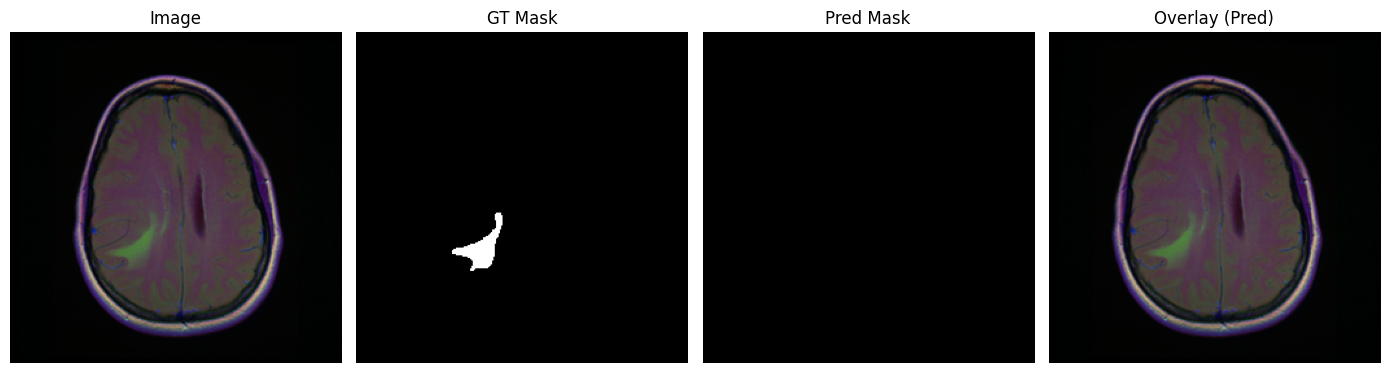

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 重新构建 dataset
data_dir = '/root/autodl-tmp/data/lgg-mri-segmentation/3m'
full_dataset = BrainTumorDataset(data_dir)

dataset_size = len(full_dataset)
val_size = int(0.2 * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size]
)

# 加载模型
model = MSFNet(num_classes=2)
model.load_state_dict(torch.load('checkpoints/best_model.pth', map_location=device))
model.to(device)
model.eval()

# 可视化
visualize_one_sample(model, val_dataset, idx=0, device=device, save_path='pred_vis.png')